# Coverage of the SIM

Here's the DGP:

$T_i \sim \text{Bernoulli}(0.5) : \text{Treatment indicator}$

$P_i \sim \text{Bernoulli}(0.5) : \text{Sample indicator (1 if Experimental)} \rightarrow \text{we only observe } T_i \text{ for the users who have } P_i=1$

$S_i(0) \sim \text{Gamma}(1, 0.2) : \text{The potential outcome representation of our surrogate under no treatment}$

$S_i(1) = S_i(0) + 0.1 : \text{Here we perturb the surrogate with the treatment effect on the surrogate}$

$S_i = T_iS_i(1) + (1-T_i)S_i(0) : \text{The realised surrogate}$

$Y_i = f(S_i)$

In the linear case:
    $Y_i = S_i$
In the non-linear case:
    $Y_i = \text{expit}(S_i)$

This set up meets all assumptions of using a SIM:
1. Unconfoundedness: $T \perp (Y(1), Y(0), S(1), S(0))$ this is met by design as $T$ is randomly assigned.
2. Comparability: $P \perp Y | S$ also met by design as $P$ is randomly assigned (in fact $P \perp Y$ unconditionally).
3. Surrogacy: $T \perp Y | S$ this is met because the only change introduced between potential outcomes is at the surrogate level i.e.:

    $Y_i(1) = f(S_i(1))$

    $Y_i(0) = f(S_i(0))$

    Impartantly this means that the ATE we defined above (0.1) is NOT the same ATE at the level of $Y$ (except for the linear function), we compute this ATE by generating both $Y_i(1)$ and $Y_i(0)$ in the simulation.


# Method
We fit a linear regression on observational data $P_i = 0$ to estimate $\hat{Y}_i = \hat{\beta}_0 + \hat{\beta}_1S_i$
* This represents historical data where we observe the long-term outcome but do not have knowledge of treatment assignment

We then take the fitted values of $\hat{Y}_j$ for $j : P_j = 1$ and run a vanilla OLS to estimate the effect of $T$ on $\hat{Y}$: under the assumptions above this is an unbiased estimate of the ATE no matter the function $f$ that we chose above


# Findings
The 95% confidence interval given by the OLS ATE estimate does not meet the 95% coverage guarantee:
* When the outcome function is linear we estimate its **coverage at around 90%**.
* When the outcome function is non-linear (a logit transform) **coverage drops to around 65%**.

In [1]:
import numpy as np
import pandas as pd
from statsmodels.formula import api as smf
from matplotlib import pyplot as plt; plt.style.use('ggplot')
import seaborn as sns

In [30]:
def linear_outcome(S):
    return S

In [31]:
def logistic_outcome(S):
    linear_combination = linear_outcome(S)
    return 1 / (1 + np.exp(-linear_combination))

In [32]:
def generate_surrogate_index_data(n=1000, seed=None, outcome_fn=linear_outcome, fn_kwargs=dict()):
    rng = np.random.default_rng(seed)
    P = rng.binomial(1, 0.5, size=n)
    T = rng.binomial(1, 0.5, size=n)
    S_0 = rng.gamma(shape=1, scale=0.2, size=n)
    S_1 = S_0 + 0.1 #< this is the treatment effect
    S = T * S_1 + (1 - T) * S_0
    Y_0 = outcome_fn(S_0, **fn_kwargs) + rng.normal(0, 0.1, size=n) # The same DGP for both potential outcomes, but with different S <- this implies surrogacy 
    Y_1 = outcome_fn(S_1, **fn_kwargs) + rng.normal(0, 0.1, size=n)
    Y = T*Y_1 + (1-T)*Y_0
    
    return pd.DataFrame({
        'P': P,
        'T': T,
        'S_0': S_0,
        'S_1': S_1,
        'S': S,
        'Y_0': Y_0,
        'Y_1': Y_1,
        'Y': Y,
    })
    

In [33]:
def generate_surrogate_index_data_sample(n=1000, seed=None, outcome_fn=linear_outcome, fn_kwargs=dict()):
    data = generate_surrogate_index_data(n=n, seed=seed, outcome_fn=outcome_fn, fn_kwargs=fn_kwargs)
    observation_data = (
        data
        .assign(
            obs_T = lambda df: np.where(df.loc[:, 'P'] == 1, df.loc[:, 'T'], np.nan),
            obs_Y = lambda df: np.where(df.loc[:, 'P'] == 0, df.loc[:, 'Y'], np.nan)
        )
    )
    return observation_data

In [34]:
SEED = 42
linear_data = generate_surrogate_index_data(10_000, seed=SEED+1, outcome_fn=linear_outcome)
non_linear_data = generate_surrogate_index_data(10_000, seed=SEED+2, outcome_fn=logistic_outcome)

In [35]:
TRUE_LOGISTIC_ATE = 0.0243991

<Axes: xlabel='S_1', ylabel='Y'>

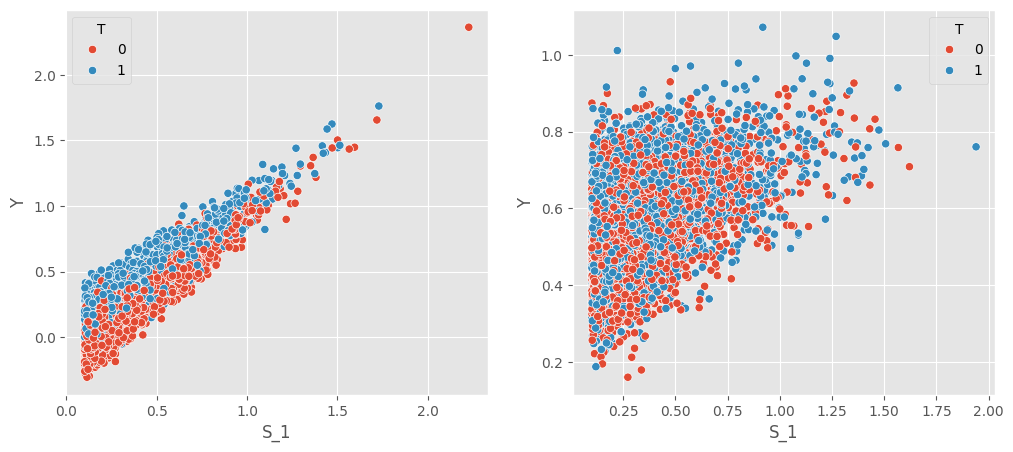

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(
    data = linear_data,
    x = 'S_1',
    y = 'Y',
    ax = ax[0],
    hue='T'
)
sns.scatterplot(
    data = non_linear_data,
    x = 'S_1',
    y = 'Y',
    ax = ax[1],
    hue='T'
)
    

In [37]:
average_treatment_effect = linear_data['Y_1'].mean() - linear_data['Y_0'].mean()
ate_stderr = np.sqrt(linear_data['Y_1'].var()/len(linear_data) + linear_data['Y_0'].var()/len(linear_data))
print(f"ATE Linear: {average_treatment_effect:.3f} ± {1.96*ate_stderr:.3f}")
average_treatment_effect = non_linear_data['Y_1'].mean() - non_linear_data['Y_0'].mean()
ate_stderr = np.sqrt(non_linear_data['Y_1'].var()/len(non_linear_data) + non_linear_data['Y_0'].var()/len(non_linear_data))
print(f"ATE Non-Linear: {average_treatment_effect:.3f} ± {1.96*ate_stderr:.3f}")

ATE Linear: 0.103 ± 0.006
ATE Non-Linear: 0.023 ± 0.003


##### Assumption 1: Unconfoundedness - met by design
$T | Y(0), Y(1)$

<Axes: xlabel='Y_1', ylabel='Density'>

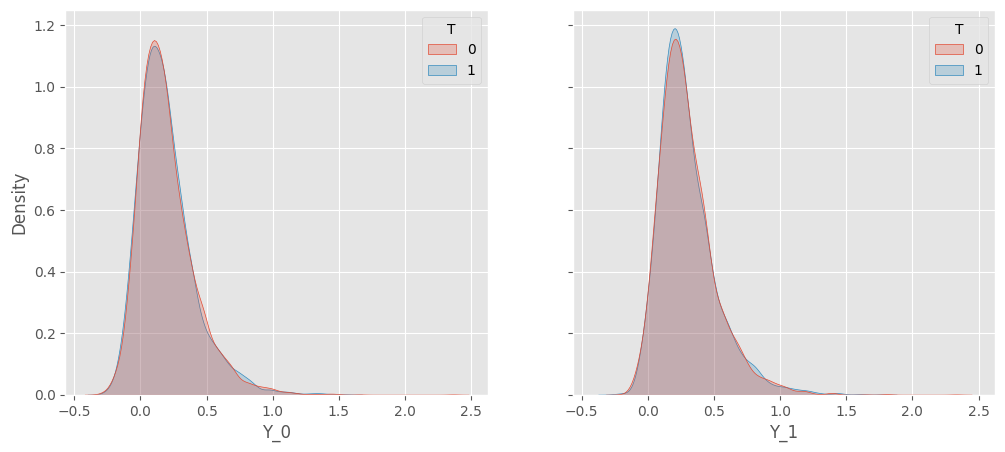

In [38]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5), sharex=True, sharey=True)
sns.kdeplot(
    data = linear_data,
    x = 'Y_0',
    hue='T',
    ax=ax[0],
    fill=True
)
sns.kdeplot(
    data = linear_data,
    x = 'Y_1',
    hue='T',
    ax=ax[1],
    fill=True
)

<Axes: xlabel='Y_1', ylabel='Density'>

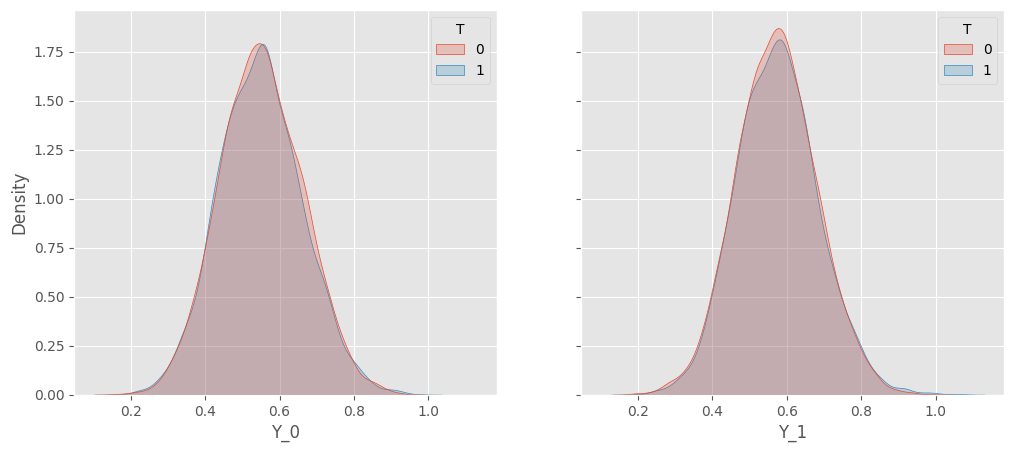

In [39]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5), sharex=True, sharey=True)
sns.kdeplot(
    data = non_linear_data,
    x = 'Y_0',
    hue='T',
    ax=ax[0],
    fill=True
)
sns.kdeplot(
    data = non_linear_data,
    x = 'Y_1',
    hue='T',
    ax=ax[1],
    fill=True
)

##### Assumption 2: Surrogacy - All of the treatment effect is mediated by the surrogates
$T \perp Y | S$

<Axes: ylabel='Y'>

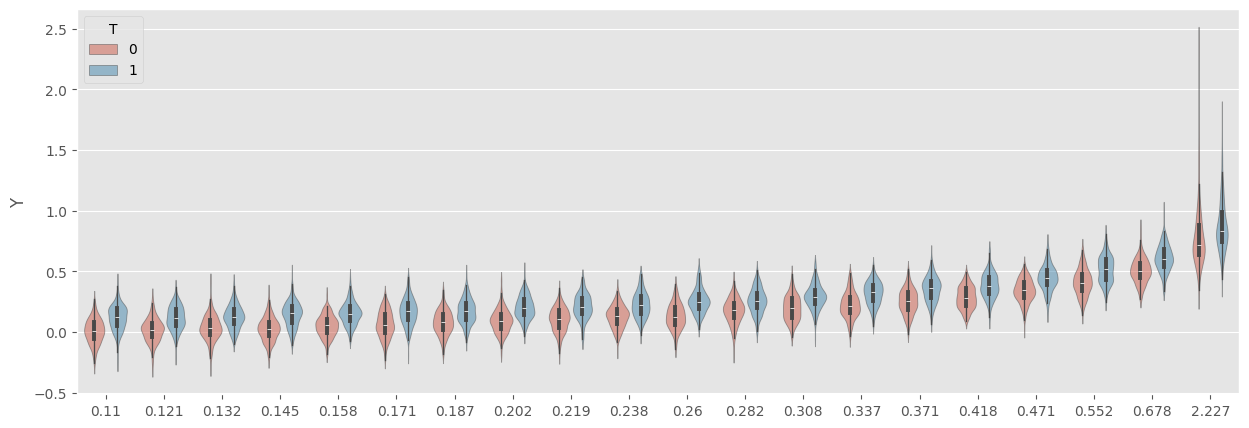

In [40]:
data = linear_data.copy()
T = data.loc[:, 'T'].to_numpy().flatten()
Y = data.loc[:, 'Y'].to_numpy().flatten()
surrogates = data.columns[data.columns.str.startswith('S_') & data.columns.map(lambda s: len(s.split('_')) == 2)]
S = data[surrogates].to_numpy()
n_surrogates = S.shape[1]
for i in range(n_surrogates):
    S_i = S[:, i]
    discrete_S_i = pd.qcut(S_i, q=20, duplicates='drop')

fig, ax = plt.subplots(figsize=(15, 5))
sns.violinplot(
    ax=ax,
    data=data,
    x=discrete_S_i.map(lambda interval: float(interval.right)),
    y='Y',
    hue='T',
    fill=True,
    alpha=0.5,
    common_norm=False
)


<Axes: ylabel='Y'>

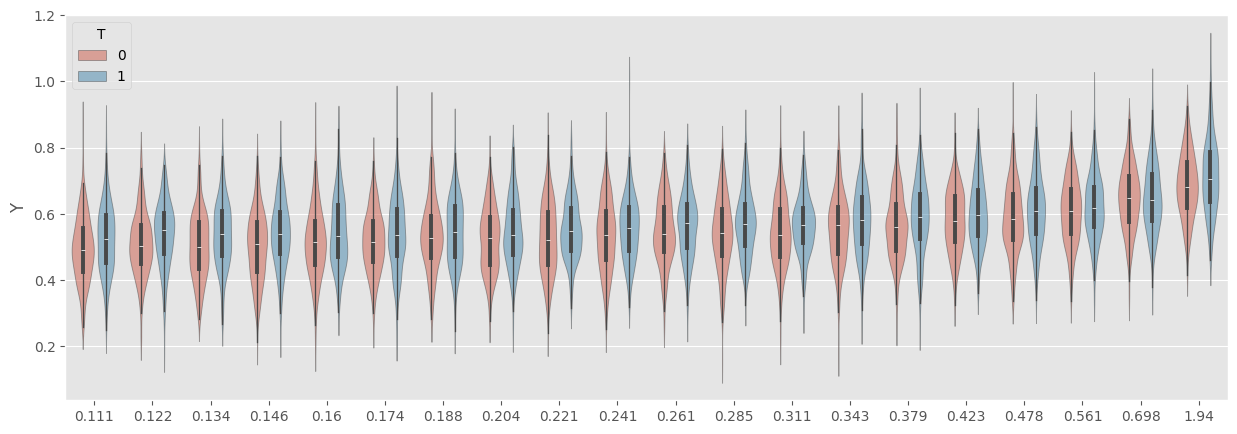

In [41]:
data = non_linear_data.copy()
T = data.loc[:, 'T'].to_numpy().flatten()
Y = data.loc[:, 'Y'].to_numpy().flatten()
surrogates = data.columns[data.columns.str.startswith('S_') & data.columns.map(lambda s: len(s.split('_')) == 2)]
S = data[surrogates].to_numpy()
n_surrogates = S.shape[1]
for i in range(n_surrogates):
    S_i = S[:, i]
    discrete_S_i = pd.qcut(S_i, q=20, duplicates='drop')

fig, ax = plt.subplots(figsize=(15, 5))
sns.violinplot(
    ax=ax,
    data=data,
    x=discrete_S_i.map(lambda interval: float(interval.right)),
    y='Y',
    hue='T',
    fill=True,
    alpha=0.5,
    common_norm=False
)


In [42]:
smf.ols('Y ~ T + S_1', data=linear_data).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                 2.041e+04
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:23:11   Log-Likelihood:                 8891.1
No. Observations:               10000   AIC:                        -1.778e+04
Df Residuals:                    9997   BIC:                        -1.775e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1021      0.002    -49.172      0.000      -0.106      -0.098
T              0.1029      0.002     51.737      0.000       0.099       0.107
S_1            1.0048      0.005    195.409      0.000       0.995       1.015
==============================================================================
Omnibus:                        0.021   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.990   Jarque-Bera (JB):                0.022
Skew:                           0.004   Prob(JB):                        0.989
Kurtosis:                       2.998   Cond. No.                         6.39
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
smf.ols('Y ~ T + S_1', data=non_linear_data).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     1158.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:23:11   Log-Likelihood:                 8803.7
No. Observations:               10000   AIC:                        -1.760e+04
Df Residuals:                    9997   BIC:                        -1.758e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4803      0.002    231.898      0.000       0.476       0.484
T              0.0235      0.002     11.705      0.000       0.020       0.027
S_1            0.2347      0.005     46.706      0.000       0.225       0.245
==============================================================================
Omnibus:                        3.500   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.174   Jarque-Bera (JB):                3.504
Skew:                           0.046   Prob(JB):                        0.173
Kurtosis:                       2.995   Cond. No.                         6.19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Assumption 3: comparability
$Y \perp P | S$

<Axes: xlabel='Y', ylabel='Density'>

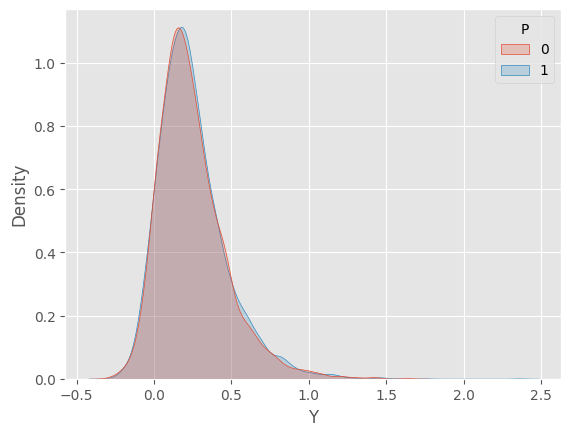

In [44]:
sns.kdeplot(
    data = linear_data,
    x = 'Y',
    hue='P',
    fill=True
)

<Axes: xlabel='Y', ylabel='Density'>

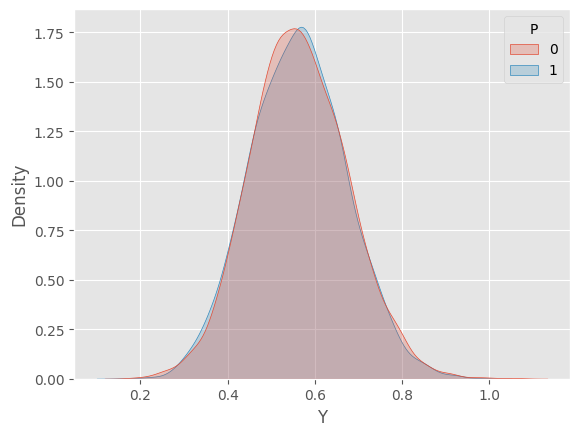

In [45]:
sns.kdeplot(
    data = non_linear_data,
    x = 'Y',
    hue='P',
    fill=True
)

# Coverage analysis

In [46]:
from tqdm import tqdm

## Linear

In [53]:
SAMPLE_SIZE = 1_000_000
true_ates = []
ates_if_y_observed = []
cis_if_y_observed = []
ates_with_sim = []
cis_with_sim = []
for seed in tqdm(list(range(100))):
    obs_data = generate_surrogate_index_data_sample(
        n=SAMPLE_SIZE,
        outcome_fn=linear_outcome,
        seed=SEED + seed
    )
    
    training_data = (
        obs_data
        .query('P == 0')
        .loc[:, ['S', 'obs_Y']]
    )
    model = smf.ols('obs_Y ~ S', data=training_data).fit()

    prediction_data = (
        obs_data
        .query('P == 1')
        .assign(
            pred_Y = lambda df: model.predict(df.loc[:, ['S']])
        )
    )

    true_ate = prediction_data['Y_1'].mean() - prediction_data['Y_0'].mean()
    true_ates.append(true_ate)

    m_ate_if_we_observed_Y = smf.ols('Y ~ T', data=prediction_data).fit()
    ate_if_obs_Y = m_ate_if_we_observed_Y.params['T']
    ate_if_obs_Y_ci = pd.Interval(*m_ate_if_we_observed_Y.conf_int().loc['T'])
    ates_if_y_observed.append(ate_if_obs_Y)
    cis_if_y_observed.append(ate_if_obs_Y_ci)


    m_ate_with_sim = smf.ols('pred_Y ~ T', data=prediction_data).fit()
    ate_with_sim = m_ate_with_sim.params['T']
    ate_with_sim_ci = pd.Interval(*m_ate_with_sim.conf_int().loc['T'])
    ates_with_sim.append(ate_with_sim)
    cis_with_sim.append(ate_with_sim_ci)



100%|██████████| 100/100 [00:17<00:00,  5.71it/s]


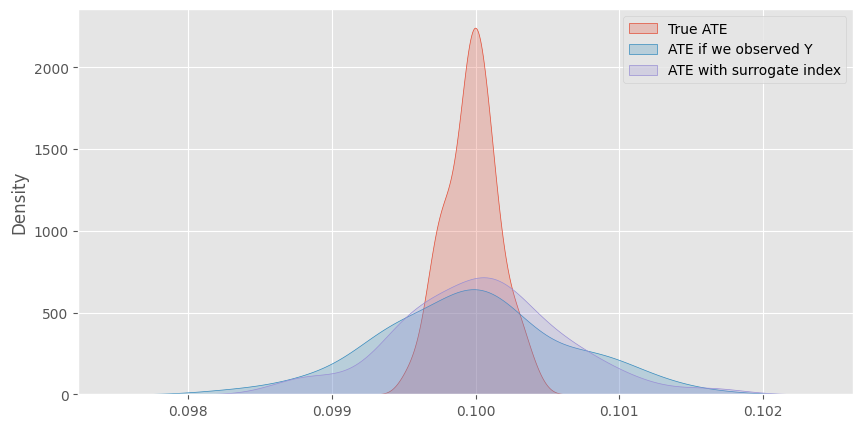

In [54]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    x=true_ates,
    fill=True,
    label='True ATE',
    ax = ax
)
sns.kdeplot(
    x=ates_if_y_observed,
    fill=True,
    label='ATE if we observed Y',
    ax=ax
)
sns.kdeplot(
    x=ates_with_sim,
    fill=True,
    label='ATE with surrogate index',
    ax=ax 
)
ax.legend()

In [57]:
coverage_if_y_observed = np.mean([true_ate in ci for ci, true_ate in zip(cis_if_y_observed, true_ates)])
coverage_with_sim = np.mean([true_ate in ci for ci, true_ate in zip(cis_with_sim, true_ates)])
print(f"Coverage if we observed Y: {coverage_if_y_observed:.3f}")
print(f"Coverage with surrogate index: {coverage_with_sim:.3f}")

Coverage if we observed Y: 0.940
Coverage with surrogate index: 0.930


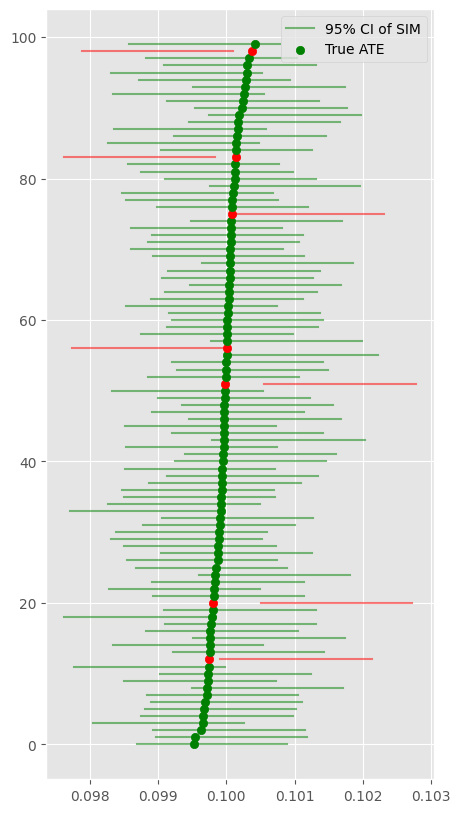

In [58]:
fig, ax = plt.subplots(figsize=(5, 10))
for idx, (ci, true_ate) in enumerate(sorted(zip(cis_with_sim, true_ates), key=lambda x: x[1])):
    if true_ate in ci:
        color = 'green'
    else:
        color = 'red'
    ax.plot([ci.left, ci.right], [idx, idx], color=color, alpha=0.5, label='95% CI of SIM' if idx == 0 else '')
    ax.scatter(true_ate, idx, color=color, label='True ATE' if idx == 0 else '', zorder=5)

ax.legend()

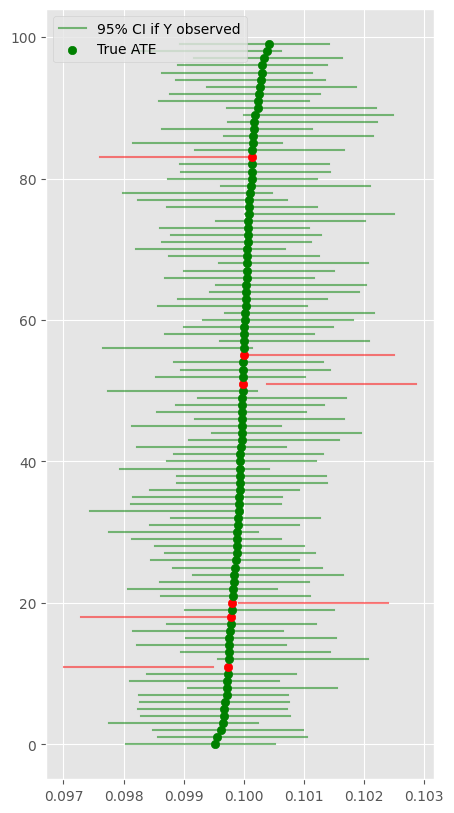

In [59]:
fig, ax = plt.subplots(figsize=(5, 10))
for idx, (ci, true_ate) in enumerate(sorted(zip(cis_if_y_observed, true_ates), key=lambda x: x[1])):
    if true_ate in ci:
        color = 'green'
    else:
        color = 'red'
    ax.plot([ci.left, ci.right], [idx, idx], color=color, alpha=0.5, label='95% CI if Y observed' if idx == 0 else '')
    ax.scatter(true_ate, idx, color=color, label='True ATE' if idx == 0 else '', zorder=5)

ax.legend()

## Non-linear

In [60]:
SAMPLE_SIZE = 1_000_000
true_ates = []
ates_if_y_observed = []
cis_if_y_observed = []
ates_with_sim = []
cis_with_sim = []
for seed in tqdm(list(range(100))):
    obs_data = generate_surrogate_index_data_sample(
        n=SAMPLE_SIZE,
        outcome_fn=logistic_outcome,
        seed=SEED + seed
    )
    
    training_data = (
        obs_data
        .query('P == 0')
        .loc[:, ['S', 'obs_Y']]
    )
    model = smf.ols('obs_Y ~ S', data=training_data).fit()

    prediction_data = (
        obs_data
        .query('P == 1')
        .assign(
            pred_Y = lambda df: model.predict(df.loc[:, ['S']])
        )
    )

    true_ate = prediction_data['Y_1'].mean() - prediction_data['Y_0'].mean()
    true_ates.append(true_ate)

    m_ate_if_we_observed_Y = smf.ols('Y ~ T', data=prediction_data).fit()
    ate_if_obs_Y = m_ate_if_we_observed_Y.params['T']
    ate_if_obs_Y_ci = pd.Interval(*m_ate_if_we_observed_Y.conf_int().loc['T'])
    ates_if_y_observed.append(ate_if_obs_Y)
    cis_if_y_observed.append(ate_if_obs_Y_ci)


    m_ate_with_sim = smf.ols('pred_Y ~ T', data=prediction_data).fit()
    ate_with_sim = m_ate_with_sim.params['T']
    ate_with_sim_ci = pd.Interval(*m_ate_with_sim.conf_int().loc['T'])
    ates_with_sim.append(ate_with_sim)
    cis_with_sim.append(ate_with_sim_ci)



100%|██████████| 100/100 [00:17<00:00,  5.69it/s]


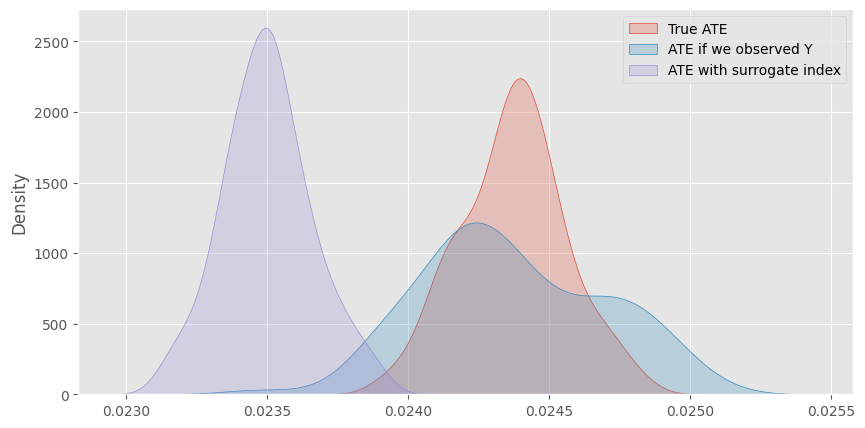

In [61]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    x=true_ates,
    fill=True,
    label='True ATE',
    ax = ax
)
sns.kdeplot(
    x=ates_if_y_observed,
    fill=True,
    label='ATE if we observed Y',
    ax=ax
)
sns.kdeplot(
    x=ates_with_sim,
    fill=True,
    label='ATE with surrogate index',
    ax=ax 
)
ax.legend()

In [62]:
coverage_if_y_observed = np.mean([true_ate in ci for ci, true_ate in zip(cis_if_y_observed, true_ates)])
coverage_with_sim = np.mean([true_ate in ci for ci, true_ate in zip(cis_with_sim, true_ates)])
print(f"Coverage if we observed Y: {coverage_if_y_observed:.3f}")
print(f"Coverage with surrogate index: {coverage_with_sim:.3f}")

Coverage if we observed Y: 0.980
Coverage with surrogate index: 0.000


In [63]:
coverage_if_y_observed = np.mean([TRUE_LOGISTIC_ATE in ci for ci in cis_if_y_observed])
coverage_with_sim = np.mean([TRUE_LOGISTIC_ATE in ci for ci in cis_with_sim])
print(f"Coverage if we observed Y: {coverage_if_y_observed:.3f}")
print(f"Coverage with surrogate index: {coverage_with_sim:.3f}")

Coverage if we observed Y: 0.980
Coverage with surrogate index: 0.000


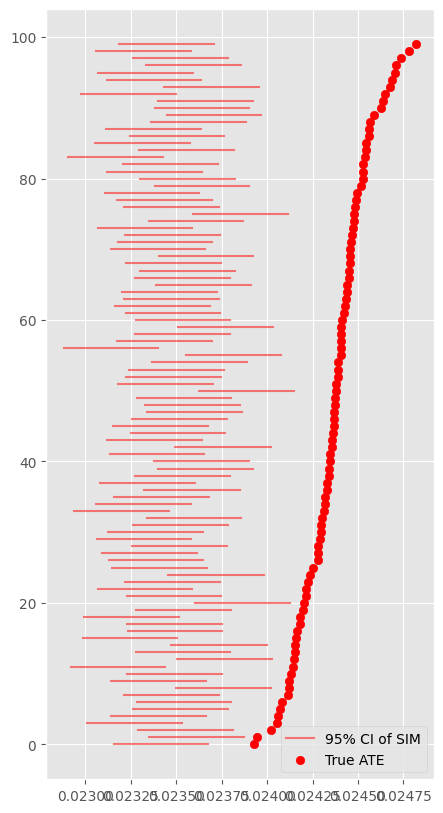

In [66]:
fig, ax = plt.subplots(figsize=(5, 10))
for idx, (ci, true_ate) in enumerate(sorted(zip(cis_with_sim, true_ates), key=lambda x: x[1])):
    if true_ate in ci:
        color = 'green'
    else:
        color = 'red'
    ax.plot([ci.left, ci.right], [idx, idx], color=color, alpha=0.5, label='95% CI of SIM' if idx == 0 else '')
    ax.scatter(true_ate, idx, color=color, label='True ATE' if idx == 0 else '', zorder=5)

ax.legend()

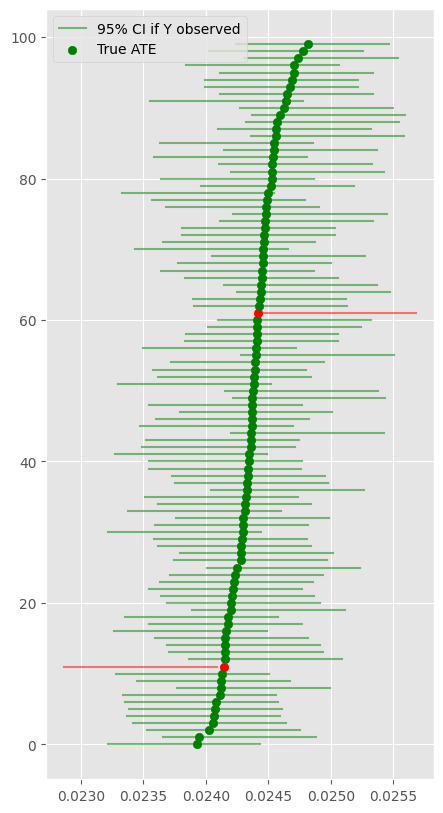

In [67]:
fig, ax = plt.subplots(figsize=(5, 10))
for idx, (ci, true_ate) in enumerate(sorted(zip(cis_if_y_observed, true_ates), key=lambda x: x[1])):
    if true_ate in ci:
        color = 'green'
    else:
        color = 'red'
    ax.plot([ci.left, ci.right], [idx, idx], color=color, alpha=0.5, label='95% CI if Y observed' if idx == 0 else '')
    ax.scatter(true_ate, idx, color=color, label='True ATE' if idx == 0 else '', zorder=5)

ax.legend()